# Installing Dependencies

In [1]:
!pip install torch torch-geometric lightgbm scikit-learn pandas numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.4 MB/s eta 0:00:00


In [2]:
!pip install networkx matplotlib

# Imports

In [16]:
from datasets import load_dataset
import numpy as np
from sklearn.model_selection import train_test_split
from datasets import ClassLabel
import pandas as pd
import torch
from torch_geometric.data import HeteroData
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import networkx as nx
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch_geometric.nn import HeteroConv, SAGEConv, MLP
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import torch.optim as optim

# Loading Dataset

In [4]:
# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset("electricsheepafrica/Nigerian-Financial-Transactions-and-Fraud-Detection-Dataset")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

V2-nigerian-financial-transactions-and-f(…):   0%|          | 0.00/1.88G [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5000000 [00:00<?, ? examples/s]

In [5]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['transaction_id', 'timestamp', 'sender_account', 'receiver_account', 'transaction_type', 'merchant_category', 'location', 'device_used', 'is_fraud', 'fraud_type', 'time_since_last_transaction', 'spending_deviation_score', 'velocity_score', 'geo_anomaly_score', 'payment_channel', 'ip_address', 'device_hash', 'amount_ngn', 'bvn_linked', 'new_device_transaction', 'sender_persona', 'geospatial_velocity_anomaly', 'txn_hour', 'is_weekend', 'is_salary_week', 'is_night_txn', 'device_seen_count', 'is_device_shared', 'ip_seen_count', 'is_ip_shared', 'user_txn_count_total', 'user_avg_txn_amt', 'user_std_txn_amt', 'user_txn_frequency_24h', 'user_top_category', 'txn_count_last_1h', 'txn_count_last_24h', 'total_amount_last_1h', 'time_since_last', 'avg_gap_between_txns', 'merchant_fraud_rate', 'channel_risk_score', 'persona_fraud_risk', 'location_fraud_risk', 'ip_geo_region'],
        num_rows: 5000000
    })
})


In [6]:
labels = ds["train"]["is_fraud"]   # loads only this column
labels = np.array(labels)

fraud_pct = labels.mean() * 100
print(f"Fraud %: {fraud_pct:.4f}%")
print(f"Non-Fraud %: {100 - fraud_pct:.4f}%")

Fraud %: 3.5911%
Non-Fraud %: 96.4089%


In [7]:
# Define class label (0 = non fraud, 1 = fraud)
class_label = ClassLabel(names=["non_fraud", "fraud"])

ds = ds["train"].cast_column("is_fraud", class_label)

Casting the dataset:   0%|          | 0/5000000 [00:00<?, ? examples/s]

In [8]:
small_ds = ds.shuffle(seed=42).select(range(200000))

In [9]:
print("Fraud %:", np.mean(small_ds["is_fraud"]) * 100)

Fraud %: 3.544


# Creating Heterogenous Graph

## Prototype Graph Construction

For prototyping, we used the **"Nigerian Financial Transactions and Fraud Detection Dataset"** [HuggingFace/Kaggle], a 5M‑transaction dataset containing sender/receiver accounts, device hashes, IP addresses, merchant categories, payment channels, and fraud labels.  

We constructed a **heterogeneous entity graph** with:
- **Nodes**: Account, Device, IP, Merchant  
- **Edges**: `transfers_to` (labelled), `uses_device`, `uses_ip`, `pays_merchant`  
- **Features**: Velocity scores, anomaly metrics, sharing flags  

This captures the cross‑channel, multi‑entity structure needed for mule detection

In [10]:
# ---------------------------------------------------
# 1. Convert the 200k HF Dataset to a pandas DataFrame
# ---------------------------------------------------
# small_ds is a datasets.Dataset with 200k rows
df = small_ds.to_pandas()

# Optional: ensure we only keep the columns we care about
# (you can adjust this list if needed)
required_cols = [
    'sender_account', 'receiver_account', 'device_hash', 'ip_address',
    'merchant_category', 'location',
    'transaction_type', 'payment_channel',
    'amount_ngn', 'is_fraud',
    'time_since_last_transaction', 'spending_deviation_score',
    'velocity_score', 'geo_anomaly_score',
    'txn_hour', 'is_weekend', 'is_salary_week', 'is_night_txn',
    'txn_count_last_1h', 'txn_count_last_24h', 'total_amount_last_1h',
    'user_txn_count_total', 'user_avg_txn_amt', 'user_std_txn_amt',
    'user_txn_frequency_24h',
    'channel_risk_score', 'persona_fraud_risk', 'location_fraud_risk',
    'device_seen_count', 'is_device_shared',
    'ip_seen_count', 'is_ip_shared',
    'merchant_fraud_rate', 'ip_geo_region', 'sender_persona', 'user_top_category'
]
df = df[required_cols].copy()

# Basic cleaning: drop rows with missing critical IDs (you can be more careful if needed)
df = df.dropna(subset=['sender_account', 'receiver_account'])

# ---------------------------------------------------
# 2. Build node ID maps for each node type
# ---------------------------------------------------

# Account nodes: all unique sender/receiver accounts
all_accounts = pd.unique(pd.concat([df['sender_account'], df['receiver_account']], ignore_index=True))
account_id2idx = {acc: i for i, acc in enumerate(all_accounts)}
num_accounts = len(all_accounts)

# Device nodes
all_devices = pd.unique(df['device_hash'].dropna())
device_id2idx = {dev: i for i, dev in enumerate(all_devices)}
num_devices = len(all_devices)

# IP nodes
all_ips = pd.unique(df['ip_address'].dropna())
ip_id2idx = {ip: i for i, ip in enumerate(all_ips)}
num_ips = len(all_ips)

# Merchant nodes (you can also use (merchant_category, location) if you want finer granularity)
all_merchants = pd.unique(df['merchant_category'].dropna())
merchant_id2idx = {m: i for i, m in enumerate(all_merchants)}
num_merchants = len(all_merchants)

print(f'#accounts={num_accounts}, #devices={num_devices}, #ips={num_ips}, #merchants={num_merchants}')

# ---------------------------------------------------
# 3. Build node feature matrices
# ---------------------------------------------------

# 3.1 Account node features
account_feature_cols = [
    'user_txn_count_total',
    'user_avg_txn_amt',
    'user_std_txn_amt',
    'user_txn_frequency_24h',
    'channel_risk_score',
    'persona_fraud_risk',
    'location_fraud_risk'
]

# Group by sender_account for these features; then reindex to all_accounts
acc_feat_df = df[['sender_account'] + account_feature_cols].copy()
acc_group = acc_feat_df.groupby('sender_account')[account_feature_cols].mean()

# Reindex to all_accounts (fill missing with 0 for accounts that only ever appear as receiver)
acc_group = acc_group.reindex(all_accounts).fillna(0.0)
account_x = acc_group.to_numpy(dtype=np.float32)
account_x = np.nan_to_num(account_x)

# 3.2 Device node features
device_feature_cols = ['device_seen_count', 'is_device_shared']
dev_feat_df = df[['device_hash'] + device_feature_cols].dropna(subset=['device_hash']).copy()
dev_group = dev_feat_df.groupby('device_hash')[device_feature_cols].mean()
dev_group = dev_group.reindex(all_devices).fillna(0.0)
device_x = dev_group.to_numpy(dtype=np.float32)
device_x = np.nan_to_num(device_x)

# 3.3 IP node features
ip_feature_cols = ['ip_seen_count', 'is_ip_shared']
ip_feat_df = df[['ip_address'] + ip_feature_cols].dropna(subset=['ip_address']).copy()
ip_group = ip_feat_df.groupby('ip_address')[ip_feature_cols].mean()
ip_group = ip_group.reindex(all_ips).fillna(0.0)
ip_x = ip_group.to_numpy(dtype=np.float32)
ip_x = np.nan_to_num(ip_x)

# 3.4 Merchant node features
merchant_feature_cols = ['merchant_fraud_rate', 'location_fraud_risk']
merch_feat_df = df[['merchant_category'] + merchant_feature_cols].dropna(subset=['merchant_category']).copy()
merch_group = merch_feat_df.groupby('merchant_category')[merchant_feature_cols].mean()
merch_group = merch_group.reindex(all_merchants).fillna(0.0)
merchant_x = merch_group.to_numpy(dtype=np.float32)
merchant_x = np.nan_to_num(merchant_x)

# ---------------------------------------------------
# 4. Build edge indices and edge features
# ---------------------------------------------------

# 4.1 TRANSFERS_TO edges (Account -> Account) with labels

# Map sender/receiver accounts to node indices
src_acc_idx = df['sender_account'].map(account_id2idx).to_numpy(dtype=np.int64)
dst_acc_idx = df['receiver_account'].map(account_id2idx).to_numpy(dtype=np.int64)

transfers_edge_index = np.stack([src_acc_idx, dst_acc_idx], axis=0)  # shape [2, num_edges]
y = df['is_fraud'].to_numpy(dtype=np.int64)  # edge labels

# Edge features: choose a compact but rich subset
numeric_edge_cols = [
    'amount_ngn',
    'time_since_last_transaction',
    'spending_deviation_score',
    'velocity_score',
    'geo_anomaly_score',
    'txn_hour',
    'is_weekend',
    'is_salary_week',
    'is_night_txn',
    'txn_count_last_1h',
    'txn_count_last_24h',
    'total_amount_last_1h'
]

# Categorical edge cols -> integer codes
cat_edge_cols = ['transaction_type', 'payment_channel', 'sender_persona', 'user_top_category']

for col in cat_edge_cols:
    codes, uniques = pd.factorize(df[col].fillna('UNK'))
    df[col + '_code'] = codes.astype(np.int64)

edge_feature_cols = numeric_edge_cols + [c + '_code' for c in cat_edge_cols]
edge_feat_arr = df[edge_feature_cols].to_numpy(dtype=np.float32)

# Standardize numeric features
scaler = StandardScaler()
num_numeric = len(numeric_edge_cols)
edge_feat_arr[:, :num_numeric] = scaler.fit_transform(
    edge_feat_arr[:, :num_numeric]
)

# 🔥 CRITICAL FIX — remove NaN / inf
edge_feat_arr = np.nan_to_num(
    edge_feat_arr,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

transfers_edge_attr = edge_feat_arr

num_edges = transfers_edge_index.shape[1]
print(f'num TRANSFERS_TO edges = {num_edges}')

# 4.2 USES_DEVICE edges (Account -> Device)
# Drop rows without a device_hash
mask_dev = df['device_hash'].notna()
src_acc_dev = df.loc[mask_dev, 'sender_account'].map(account_id2idx).to_numpy(dtype=np.int64)
dst_dev = df.loc[mask_dev, 'device_hash'].map(device_id2idx).to_numpy(dtype=np.int64)
uses_device_edge_index = np.stack([src_acc_dev, dst_dev], axis=0)

# 4.3 USES_IP edges (Account -> IP)
mask_ip = df['ip_address'].notna()
src_acc_ip = df.loc[mask_ip, 'sender_account'].map(account_id2idx).to_numpy(dtype=np.int64)
dst_ip = df.loc[mask_ip, 'ip_address'].map(ip_id2idx).to_numpy(dtype=np.int64)
uses_ip_edge_index = np.stack([src_acc_ip, dst_ip], axis=0)

# 4.4 PAYS_MERCHANT edges (Account -> Merchant)
mask_merch = df['merchant_category'].notna()
src_acc_merch = df.loc[mask_merch, 'sender_account'].map(account_id2idx).to_numpy(dtype=np.int64)
dst_merch = df.loc[mask_merch, 'merchant_category'].map(merchant_id2idx).to_numpy(dtype=np.int64)
pays_merchant_edge_index = np.stack([src_acc_merch, dst_merch], axis=0)

# (Optional) 4.5 WITHDRAWS_AT edges (if you can identify ATM/POS from payment_channel)
# Example sketch – adjust channel values to your data:
# atm_mask = df['payment_channel'].str.upper().eq('ATM')
# pos_mask = df['payment_channel'].str.upper().eq('POS')
# ...

# ---------------------------------------------------
# 5. Create train/val/test splits on TRANSFERS_TO edges
# ---------------------------------------------------
all_edge_idx = np.arange(num_edges)
y_edges = y

# 70% train, 15% val, 15% test (all stratified)
train_idx, temp_idx, y_train, y_temp = train_test_split(
    all_edge_idx, y_edges, test_size=0.30, stratify=y_edges, random_state=42
)
val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

train_mask = np.zeros(num_edges, dtype=bool)
val_mask = np.zeros(num_edges, dtype=bool)
test_mask = np.zeros(num_edges, dtype=bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

# Class weight for BCEWithLogitsLoss(pos_weight=...)
num_pos = y_edges.sum()
num_neg = len(y_edges) - num_pos
pos_weight = torch.tensor([num_neg / max(num_pos, 1)], dtype=torch.float32)
print(f'Class pos_weight for loss = {pos_weight.item():.2f}')

# ---------------------------------------------------
# 6. Build the PyG HeteroData object
# ---------------------------------------------------
data = HeteroData()

# Node features
data['account'].x = torch.from_numpy(account_x)          # [num_accounts, d_acc]
data['device'].x  = torch.from_numpy(device_x)          # [num_devices, d_dev]
data['ip'].x      = torch.from_numpy(ip_x)              # [num_ips, d_ip]
data['merchant'].x= torch.from_numpy(merchant_x)        # [num_merchants, d_merch]

# TRANSFERS_TO edge store (this is your supervised target)
data['account', 'transfers_to', 'account'].edge_index = torch.from_numpy(transfers_edge_index)
data['account', 'transfers_to', 'account'].edge_attr  = torch.from_numpy(transfers_edge_attr)
data['account', 'transfers_to', 'account'].y          = torch.from_numpy(y_edges).long()

data['account', 'transfers_to', 'account'].train_mask = torch.from_numpy(train_mask)
data['account', 'transfers_to', 'account'].val_mask   = torch.from_numpy(val_mask)
data['account', 'transfers_to', 'account'].test_mask  = torch.from_numpy(test_mask)

# USES_DEVICE edges
data['account', 'uses_device', 'device'].edge_index = torch.from_numpy(uses_device_edge_index)

# USES_IP edges
data['account', 'uses_ip', 'ip'].edge_index = torch.from_numpy(uses_ip_edge_index)

# PAYS_MERCHANT edges
data['account', 'pays_merchant', 'merchant'].edge_index = torch.from_numpy(pays_merchant_edge_index)

print(data)

#accounts=323220, #devices=197717, #ips=110403, #merchants=21
num TRANSFERS_TO edges = 200000
Class pos_weight for loss = 27.22
HeteroData(
  account={ x=[323220, 7] },
  device={ x=[197717, 2] },
  ip={ x=[110403, 2] },
  merchant={ x=[21, 2] },
  (account, transfers_to, account)={
    edge_index=[2, 200000],
    edge_attr=[200000, 16],
    y=[200000],
    train_mask=[200000],
    val_mask=[200000],
    test_mask=[200000],
  },
  (account, uses_device, device)={ edge_index=[2, 200000] },
  (account, uses_ip, ip)={ edge_index=[2, 200000] },
  (account, pays_merchant, merchant)={ edge_index=[2, 200000] }
)


Center account node index: 128680
Ego subgraph: 1 accounts, 0 transfers edges
Extra nodes: 1 devices, 1 IPs, 1 merchants
Total nodes in drawn subgraph: 4
Total edges in drawn subgraph: 3


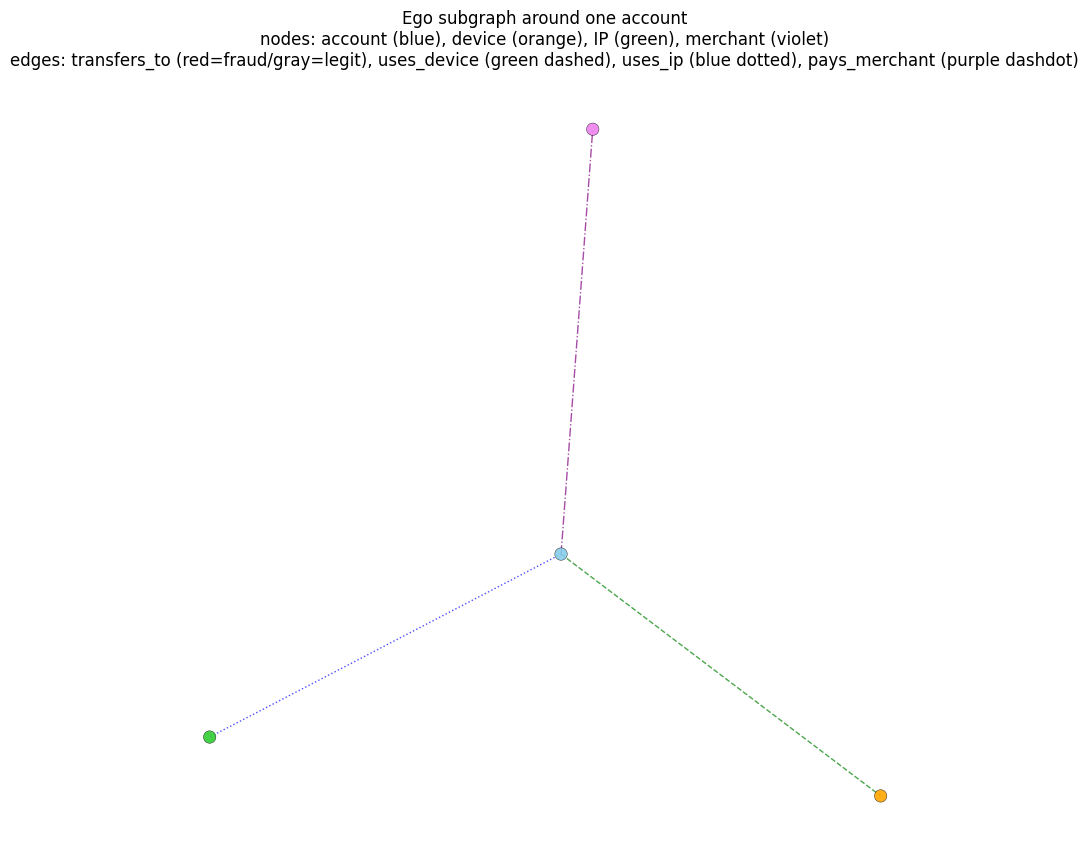

In [12]:
# ---------------------------------------------------
# 1. Convenience handles
# ---------------------------------------------------
trans = data['account', 'transfers_to', 'account']
uses_dev = data['account', 'uses_device', 'device']
uses_ip  = data['account', 'uses_ip', 'ip']
pays_merch = data['account', 'pays_merchant', 'merchant']

edge_index = trans.edge_index.numpy()
edge_labels = trans.y.numpy()
src, dst = edge_index

# ---------------------------------------------------
# 2. Pick a "center" account and build a small ego graph
#    We'll pick an account involved in at least one fraud edge so we can see red edges.
# ---------------------------------------------------
fraud_edges_idx = np.where(edge_labels == 1)[0]
if len(fraud_edges_idx) == 0:
    # fallback: just pick a random edge
    center_edge = np.random.randint(len(edge_labels))
else:
    center_edge = np.random.choice(fraud_edges_idx)

center_acc = int(src[center_edge])  # you can also use dst[center_edge]

print("Center account node index:", center_acc)

# 1-hop neighbors via transfers_to
neighbors_acc = set([center_acc])
neighbors_acc.update(src[edge_index[0] == center_acc])
neighbors_acc.update(dst[edge_index[1] == center_acc])

# Optionally limit size
max_accounts = 40
if len(neighbors_acc) > max_accounts:
    neighbors_acc = set(np.random.choice(list(neighbors_acc), size=max_accounts, replace=False))

neighbors_acc = sorted(list(neighbors_acc))

# Build mask for transfers inside this small account set
mask_trans = np.isin(src, neighbors_acc) & np.isin(dst, neighbors_acc)
sub_src = src[mask_trans]
sub_dst = dst[mask_trans]
sub_y   = edge_labels[mask_trans]

print(f"Ego subgraph: {len(neighbors_acc)} accounts, {len(sub_y)} transfers edges")

# ---------------------------------------------------
# 3. Bring in connected devices, IPs, merchants for these accounts
# ---------------------------------------------------
neighbors_acc_arr = np.array(neighbors_acc)

# USES_DEVICE
ud_src, ud_dst = uses_dev.edge_index.numpy()
mask_ud = np.isin(ud_src, neighbors_acc_arr)
sub_ud_src = ud_src[mask_ud]
sub_ud_dst = ud_dst[mask_ud]
unique_devices = np.unique(sub_ud_dst)

# USES_IP
ui_src, ui_dst = uses_ip.edge_index.numpy()
mask_ui = np.isin(ui_src, neighbors_acc_arr)
sub_ui_src = ui_src[mask_ui]
sub_ui_dst = ui_dst[mask_ui]
unique_ips = np.unique(sub_ui_dst)

# PAYS_MERCHANT
pm_src, pm_dst = pays_merch.edge_index.numpy()
mask_pm = np.isin(pm_src, neighbors_acc_arr)
sub_pm_src = pm_src[mask_pm]
sub_pm_dst = pm_dst[mask_pm]
unique_merchs = np.unique(sub_pm_dst)

print(f"Extra nodes: {len(unique_devices)} devices, {len(unique_ips)} IPs, {len(unique_merchs)} merchants")

# Optionally cap each to avoid clutter
def cap(arr, k):
    if len(arr) > k:
        return np.random.choice(arr, size=k, replace=False)
    return arr

unique_devices = cap(unique_devices, 30)
unique_ips     = cap(unique_ips, 30)
unique_merchs  = cap(unique_merchs, 10)

# Re-mask edges after capping
mask_ud = np.isin(sub_ud_dst, unique_devices)
sub_ud_src = sub_ud_src[mask_ud]
sub_ud_dst = sub_ud_dst[mask_ud]

mask_ui = np.isin(sub_ui_dst, unique_ips)
sub_ui_src = sub_ui_src[mask_ui]
sub_ui_dst = sub_ui_dst[mask_ui]

mask_pm = np.isin(sub_pm_dst, unique_merchs)
sub_pm_src = sub_pm_src[mask_pm]
sub_pm_dst = sub_pm_dst[mask_pm]

# ---------------------------------------------------
# 4. Build a NetworkX graph with node/edge types
# ---------------------------------------------------
G = nx.Graph()  # undirected for visualization

# Add account nodes
for acc in neighbors_acc:
    G.add_node(('account', int(acc)), ntype='account')

# Add device nodes
for d in unique_devices:
    G.add_node(('device', int(d)), ntype='device')

# Add IP nodes
for ip in unique_ips:
    G.add_node(('ip', int(ip)), ntype='ip')

# Add merchant nodes
for m in unique_merchs:
    G.add_node(('merchant', int(m)), ntype='merchant')

# Add transfers_to edges (Account-Account), mark fraud
for s, d, lbl in zip(sub_src, sub_dst, sub_y):
    G.add_edge(('account', int(s)), ('account', int(d)),
               etype='transfers_to', fraud=int(lbl))

# Add uses_device edges
for s, d in zip(sub_ud_src, sub_ud_dst):
    G.add_edge(('account', int(s)), ('device', int(d)),
               etype='uses_device', fraud=0)

# Add uses_ip edges
for s, d in zip(sub_ui_src, sub_ui_dst):
    G.add_edge(('account', int(s)), ('ip', int(d)),
               etype='uses_ip', fraud=0)

# Add pays_merchant edges
for s, d in zip(sub_pm_src, sub_pm_dst):
    G.add_edge(('account', int(s)), ('merchant', int(d)),
               etype='pays_merchant', fraud=0)

print("Total nodes in drawn subgraph:", G.number_of_nodes())
print("Total edges in drawn subgraph:", G.number_of_edges())

# ---------------------------------------------------
# 5. Plot with different colors per node/edge type
# ---------------------------------------------------
plt.figure(figsize=(10, 10))

pos = nx.spring_layout(G, k=0.25, iterations=100)

# Node colors by type
node_colors = []
for n, attrs in G.nodes(data=True):
    t = attrs['ntype']
    if t == 'account':
        node_colors.append('skyblue')
    elif t == 'device':
        node_colors.append('orange')
    elif t == 'ip':
        node_colors.append('limegreen')
    elif t == 'merchant':
        node_colors.append('violet')
    else:
        node_colors.append('gray')

nx.draw_networkx_nodes(G, pos,
                       node_size=80,
                       node_color=node_colors,
                       alpha=0.9,
                       linewidths=0.3,
                       edgecolors='black')

# Edge subsets
trans_fraud = [(u, v) for u, v, a in G.edges(data=True)
               if a.get('etype') == 'transfers_to' and a.get('fraud', 0) == 1]
trans_legit = [(u, v) for u, v, a in G.edges(data=True)
               if a.get('etype') == 'transfers_to' and a.get('fraud', 0) == 0]
uses_device_edges = [(u, v) for u, v, a in G.edges(data=True)
                     if a.get('etype') == 'uses_device']
uses_ip_edges = [(u, v) for u, v, a in G.edges(data=True)
                 if a.get('etype') == 'uses_ip']
pays_merch_edges = [(u, v) for u, v, a in G.edges(data=True)
                    if a.get('etype') == 'pays_merchant']

# Draw edges by type
nx.draw_networkx_edges(G, pos,
                       edgelist=trans_legit,
                       edge_color='lightgray',
                       width=1.0,
                       alpha=0.7)
nx.draw_networkx_edges(G, pos,
                       edgelist=trans_fraud,
                       edge_color='red',
                       width=2.0,
                       alpha=0.9)
nx.draw_networkx_edges(G, pos,
                       edgelist=uses_device_edges,
                       edge_color='green',
                       style='dashed',
                       width=1.0,
                       alpha=0.7)
nx.draw_networkx_edges(G, pos,
                       edgelist=uses_ip_edges,
                       edge_color='blue',
                       style='dotted',
                       width=1.0,
                       alpha=0.7)
nx.draw_networkx_edges(G, pos,
                       edgelist=pays_merch_edges,
                       edge_color='purple',
                       style='dashdot',
                       width=1.0,
                       alpha=0.7)

plt.title('Ego subgraph around one account\n'
          'nodes: account (blue), device (orange), IP (green), merchant (violet)\n'
          'edges: transfers_to (red=fraud/gray=legit), uses_device (green dashed), '
          'uses_ip (blue dotted), pays_merchant (purple dashdot)')
plt.axis('off')
plt.show()


Subgraph (many centers): 100 accounts, 0 transfers edges
Multi-center nodes: 242 edges: 186


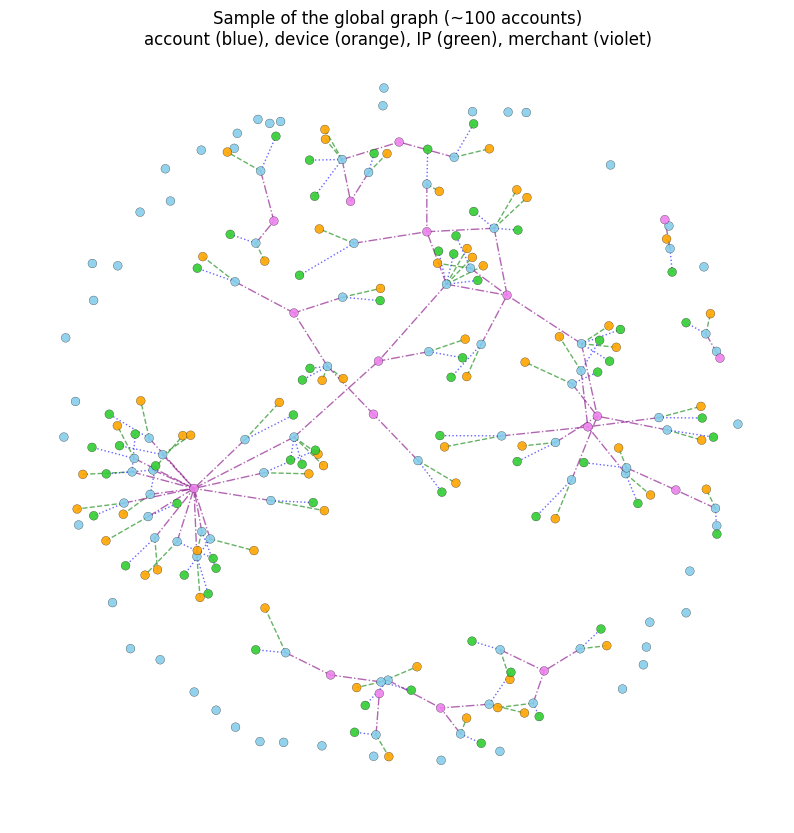

In [13]:
trans = data['account', 'transfers_to', 'account']
uses_dev = data['account', 'uses_device', 'device']
uses_ip  = data['account', 'uses_ip', 'ip']
pays_merch = data['account', 'pays_merchant', 'merchant']

edge_index = trans.edge_index.numpy()
edge_labels = trans.y.numpy()
src, dst = edge_index

# --- choose a set of ~100 accounts present in transfers_to edges ---
all_accounts_in_edges = np.unique(np.concatenate([src, dst]))
k_accounts = 100
if len(all_accounts_in_edges) > k_accounts:
    sampled_accounts = np.random.choice(all_accounts_in_edges, size=k_accounts, replace=False)
else:
    sampled_accounts = all_accounts_in_edges

sampled_accounts = np.array(sampled_accounts)

# all transfers among those 100 accounts
mask_trans = np.isin(src, sampled_accounts) & np.isin(dst, sampled_accounts)
sub_src = src[mask_trans]
sub_dst = dst[mask_trans]
sub_y   = edge_labels[mask_trans]

print(f"Subgraph (many centers): {len(sampled_accounts)} accounts, {len(sub_y)} transfers edges")

# --- devices/IPs/merchants for these accounts ---
ud_src, ud_dst = uses_dev.edge_index.numpy()
ui_src, ui_dst = uses_ip.edge_index.numpy()
pm_src, pm_dst = pays_merch.edge_index.numpy()

mask_ud = np.isin(ud_src, sampled_accounts)
mask_ui = np.isin(ui_src, sampled_accounts)
mask_pm = np.isin(pm_src, sampled_accounts)

sub_ud_src = ud_src[mask_ud]; sub_ud_dst = ud_dst[mask_ud]
sub_ui_src = ui_src[mask_ui]; sub_ui_dst = ui_dst[mask_ui]
sub_pm_src = pm_src[mask_pm]; sub_pm_dst = pm_dst[mask_pm]

unique_devices = np.unique(sub_ud_dst)
unique_ips     = np.unique(sub_ui_dst)
unique_merchs  = np.unique(sub_pm_dst)

# cap to keep plot readable
def cap(arr, k):
    if len(arr) > k:
        return np.random.choice(arr, size=k, replace=False)
    return arr

unique_devices = cap(unique_devices, 80)
unique_ips     = cap(unique_ips, 80)
unique_merchs  = cap(unique_merchs, 20)

mask_ud = np.isin(sub_ud_dst, unique_devices)
sub_ud_src = sub_ud_src[mask_ud]; sub_ud_dst = sub_ud_dst[mask_ud]
mask_ui = np.isin(sub_ui_dst, unique_ips)
sub_ui_src = sub_ui_src[mask_ui]; sub_ui_dst = sub_ui_dst[mask_ui]
mask_pm = np.isin(sub_pm_dst, unique_merchs)
sub_pm_src = sub_pm_src[mask_pm]; sub_pm_dst = sub_pm_dst[mask_pm]

# --- build NetworkX graph ---
G = nx.Graph()

for acc in sampled_accounts:
    G.add_node(('account', int(acc)), ntype='account')
for d in unique_devices:
    G.add_node(('device', int(d)), ntype='device')
for ip in unique_ips:
    G.add_node(('ip', int(ip)), ntype='ip')
for m in unique_merchs:
    G.add_node(('merchant', int(m)), ntype='merchant')

for s, d, lbl in zip(sub_src, sub_dst, sub_y):
    G.add_edge(('account', int(s)), ('account', int(d)),
               etype='transfers_to', fraud=int(lbl))
for s, d in zip(sub_ud_src, sub_ud_dst):
    G.add_edge(('account', int(s)), ('device', int(d)), etype='uses_device', fraud=0)
for s, d in zip(sub_ui_src, sub_ui_dst):
    G.add_edge(('account', int(s)), ('ip', int(d)), etype='uses_ip', fraud=0)
for s, d in zip(sub_pm_src, sub_pm_dst):
    G.add_edge(('account', int(s)), ('merchant', int(d)), etype='pays_merchant', fraud=0)

print("Multi-center nodes:", G.number_of_nodes(), "edges:", G.number_of_edges())

# --- plot ---
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G, k=0.35, iterations=150)

node_colors = []
for n, attrs in G.nodes(data=True):
    t = attrs['ntype']
    if t == 'account':
        node_colors.append('skyblue')
    elif t == 'device':
        node_colors.append('orange')
    elif t == 'ip':
        node_colors.append('limegreen')
    else:
        node_colors.append('violet')

nx.draw_networkx_nodes(G, pos, node_size=40, node_color=node_colors,
                       alpha=0.9, linewidths=0.2, edgecolors='black')

trans_fraud = [(u, v) for u, v, a in G.edges(data=True)
               if a.get('etype') == 'transfers_to' and a.get('fraud', 0) == 1]
trans_legit = [(u, v) for u, v, a in G.edges(data=True)
               if a.get('etype') == 'transfers_to' and a.get('fraud', 0) == 0]
uses_device_edges = [(u, v) for u, v, a in G.edges(data=True) if a.get('etype') == 'uses_device']
uses_ip_edges     = [(u, v) for u, v, a in G.edges(data=True) if a.get('etype') == 'uses_ip']
pays_merch_edges  = [(u, v) for u, v, a in G.edges(data=True) if a.get('etype') == 'pays_merchant']

nx.draw_networkx_edges(G, pos, edgelist=trans_legit, edge_color='lightgray', width=0.8, alpha=0.6)
nx.draw_networkx_edges(G, pos, edgelist=trans_fraud, edge_color='red', width=1.5, alpha=0.9)
nx.draw_networkx_edges(G, pos, edgelist=uses_device_edges, edge_color='green', style='dashed', alpha=0.6)
nx.draw_networkx_edges(G, pos, edgelist=uses_ip_edges, edge_color='blue', style='dotted', alpha=0.6)
nx.draw_networkx_edges(G, pos, edgelist=pays_merch_edges, edge_color='purple', style='dashdot', alpha=0.6)

plt.title('Sample of the global graph (~100 accounts)\n'
          'account (blue), device (orange), IP (green), merchant (violet)')
plt.axis('off')
plt.show()


# Training Model

## Model Prototype and Production Pipeline

**Prototype**: We implemented a **heterogeneous GraphSAGE (SAGEConv)** baseline with relation‑specific message passing across all edge types, followed by an MLP edge classifier for fraud prediction on `transfers_to` edges. Class‑weighted loss handles the 3.6% fraud imbalance.  

**Production Pipeline**: For deployment, we propose **CAV‑HGNN** (Camouflage- and Velocity-Aware Heterogeneous Graph Neural Network):  
- **Risk‑aware neighbor sampling** (CARE‑GNN‑inspired) to combat camouflage.  
- **Temporal decay weighting** for high‑velocity patterns.  
- **Edge‑to‑account risk aggregation** → mule flagging via thresholding.  

The prototype validates the heterogeneous graph approach; production adds mule‑specific enhancements.


In [24]:
# ---------------------------------------------------
# 1. MODEL
# ---------------------------------------------------
class HeteroEdgeClassifier(torch.nn.Module):
    def __init__(self, hidden_channels=64, edge_feat_dim=16):
        super().__init__()

        input_dims = {
            'account': data['account'].x.size(1),
            'device': data['device'].x.size(1),
            'ip': data['ip'].x.size(1),
            'merchant': data['merchant'].x.size(1)
        }

        self.conv1 = HeteroConv({
                ('account', 'transfers_to', 'account'):
                    SAGEConv((input_dims['account'], input_dims['account']), hidden_channels),

                ('account', 'uses_device', 'device'):
                    SAGEConv((input_dims['account'], input_dims['device']), hidden_channels),

                ('account', 'uses_ip', 'ip'):
                    SAGEConv((input_dims['account'], input_dims['ip']), hidden_channels),

                ('account', 'pays_merchant', 'merchant'):
                    SAGEConv((input_dims['account'], input_dims['merchant']), hidden_channels),

                ('device', 'to', 'account'):
                    SAGEConv((input_dims['device'], input_dims['account']), hidden_channels),

                ('ip', 'to', 'account'):
                    SAGEConv((input_dims['ip'], input_dims['account']), hidden_channels),

                ('merchant', 'to', 'account'):
                    SAGEConv((input_dims['merchant'], input_dims['account']), hidden_channels),
            }, aggr='sum')

        self.conv2 = HeteroConv({
              ('account', 'transfers_to', 'account'):
                  SAGEConv((hidden_channels, hidden_channels), hidden_channels),

              ('account', 'uses_device', 'device'):
                  SAGEConv((hidden_channels, hidden_channels), hidden_channels),

              ('account', 'uses_ip', 'ip'):
                  SAGEConv((hidden_channels, hidden_channels), hidden_channels),

              ('account', 'pays_merchant', 'merchant'):
                  SAGEConv((hidden_channels, hidden_channels), hidden_channels),

              ('device', 'to', 'account'):
                  SAGEConv((hidden_channels, hidden_channels), hidden_channels),

              ('ip', 'to', 'account'):
                  SAGEConv((hidden_channels, hidden_channels), hidden_channels),

              ('merchant', 'to', 'account'):
                  SAGEConv((hidden_channels, hidden_channels), hidden_channels),
          }, aggr='mean')

        self.edge_mlp = MLP([
            2 * hidden_channels + edge_feat_dim,
            hidden_channels,
            hidden_channels // 2,
            1
        ], dropout=0.1)

    def forward(self, x_dict, edge_index_dict):
        x = self.conv1(x_dict, edge_index_dict)
        x = {k: F.relu(v) for k, v in x.items()}

        x = self.conv2(x, edge_index_dict)
        x = {k: F.dropout(v, p=0.1, training=self.training) for k, v in x.items()}

        return x

    def predict_edge(self, x_dict, edge_index, edge_attr):
        src, dst = edge_index
        src_emb = x_dict['account'][src]
        dst_emb = x_dict['account'][dst]
        edge_emb = torch.cat([src_emb, dst_emb, edge_attr], dim=-1)
        return self.edge_mlp(edge_emb).squeeze(-1)


# ---------------------------------------------------
# 2. METRICS
# ---------------------------------------------------
def compute_auc(pred, target):
    return roc_auc_score(target.cpu(), pred.cpu())

def compute_ap(pred, target):
    return average_precision_score(target.cpu(), pred.cpu())


# ---------------------------------------------------
# 3. CPU TRAINING SETUP
# ---------------------------------------------------
torch.set_num_threads(4)

device = torch.device('cpu')
data = data.to(device)

model = HeteroEdgeClassifier(
    hidden_channels=64,
    edge_feat_dim=data['account', 'transfers_to', 'account'].edge_attr.size(1)
).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)


# ---------------------------------------------------
# 4. TRAIN FUNCTION (FULL BATCH)
# ---------------------------------------------------
def train_epoch(model, data, optimizer):
    model.train()
    optimizer.zero_grad()

    x_dict = model(data.x_dict, data.edge_index_dict)
    edge_store = data['account', 'transfers_to', 'account']

    pred = model.predict_edge(
        x_dict,
        edge_store.edge_index,
        edge_store.edge_attr
    )

    target = edge_store.y.float()
    train_mask = edge_store.train_mask

    loss = F.binary_cross_entropy_with_logits(
        pred[train_mask],
        target[train_mask],
        pos_weight=pos_weight
    )

    loss.backward()
    optimizer.step()

    with torch.no_grad():
        train_auc = compute_auc(pred[train_mask].sigmoid(), target[train_mask])
        train_ap  = compute_ap(pred[train_mask].sigmoid(), target[train_mask])

    return loss.item(), train_auc, train_ap


# ---------------------------------------------------
# 5. EVALUATION
# ---------------------------------------------------
def evaluate(model, data, mode='val', threshold=0.5):
    model.eval()
    with torch.no_grad():
        x_dict = model(data.x_dict, data.edge_index_dict)
        edge_store = data['account', 'transfers_to', 'account']

        prob = model.predict_edge(
            x_dict,
            edge_store.edge_index,
            edge_store.edge_attr
        ).sigmoid()

        target = edge_store.y.float()
        mask = edge_store[f'{mode}_mask']

        prob = prob[mask]
        target = target[mask]

        pred = (prob > threshold).float()

        precision = precision_score(target.cpu(), pred.cpu(), zero_division=0)
        recall    = recall_score(target.cpu(), pred.cpu(), zero_division=0)
        f1        = f1_score(target.cpu(), pred.cpu(), zero_division=0)
        acc       = accuracy_score(target.cpu(), pred.cpu())

        return precision, recall, f1, acc

# ---------------------------------------------------
# 6. TRAIN LOOP
# ---------------------------------------------------
epochs = 10

print("Epoch | Val P | Val R | Val F1 | Val Acc | Test P | Test R | Test F1 | Test Acc")

for epoch in range(epochs):
    loss, train_auc, train_ap = train_epoch(model, data, optimizer)

    val_p, val_r, val_f1, val_acc = evaluate(model, data, 'val')
    test_p, test_r, test_f1, test_acc = evaluate(model, data, 'test')

    print(f"{epoch:02d} | "
          f"{val_p:.4f} {val_r:.4f} {val_f1:.4f} {val_acc:.4f} | "
          f"{test_p:.4f} {test_r:.4f} {test_f1:.4f} {test_acc:.4f}")

# ---------------------------------------------------
# 7. SAVE MODEL
# ---------------------------------------------------
torch.save(model.state_dict(), 'hetero_edge_classifier_cpu.pt')
print("Model saved as hetero_edge_classifier_cpu.pt")

Epoch | Val P | Val R | Val F1 | Val Acc | Test P | Test R | Test F1 | Test Acc
00 | 0.0359 0.5381 0.0673 0.4719 | 0.0349 0.5174 0.0653 0.4753
01 | 0.0359 0.2747 0.0636 0.7132 | 0.0342 0.2596 0.0605 0.7141
02 | 0.0392 0.0235 0.0294 0.9450 | 0.0342 0.0216 0.0265 0.9437
03 | 0.0457 0.0179 0.0257 0.9520 | 0.0373 0.0151 0.0214 0.9513
04 | 0.0408 0.0169 0.0239 0.9511 | 0.0424 0.0179 0.0251 0.9509
05 | 0.0385 0.0179 0.0244 0.9494 | 0.0384 0.0179 0.0244 0.9493
06 | 0.0357 0.0188 0.0246 0.9472 | 0.0486 0.0273 0.0349 0.9466
07 | 0.0352 0.0226 0.0275 0.9435 | 0.0475 0.0329 0.0389 0.9423
08 | 0.0365 0.0423 0.0392 0.9265 | 0.0449 0.0536 0.0489 0.9260
09 | 0.0338 0.0809 0.0477 0.8856 | 0.0380 0.0941 0.0541 0.8834
Model saved as hetero_edge_classifier_cpu.pt


# Prediction using Model

In [27]:
# ---------------------------------------------------
# Weighted Mean Account Risk (SAFE VERSION)
# ---------------------------------------------------

# Get edge index as torch tensor
edge_index = data['account', 'transfers_to', 'account'].edge_index

# Ensure src and dst are torch tensors on correct device
src = torch.as_tensor(edge_index[0], dtype=torch.long)
dst = torch.as_tensor(edge_index[1], dtype=torch.long)

# Ensure they are on same device as fraud_probs
src = src.to(fraud_probs.device)
dst = dst.to(fraud_probs.device)

# Number of accounts
num_accounts = data['account'].x.size(0)

# Get transaction amounts (first column of edge_attr)
amounts = data['account', 'transfers_to', 'account'].edge_attr[:, 0]
amounts = torch.as_tensor(amounts, dtype=torch.float32).to(fraud_probs.device)

# Compute weighted fraud probabilities
weighted_probs = fraud_probs * amounts

# Initialize accumulators
account_weighted_sum = torch.zeros(num_accounts, device=fraud_probs.device)
account_amount_sum = torch.zeros(num_accounts, device=fraud_probs.device)

# Aggregate for source accounts
account_weighted_sum.scatter_add_(0, src, weighted_probs)
account_amount_sum.scatter_add_(0, src, amounts)

# Aggregate for destination accounts
account_weighted_sum.scatter_add_(0, dst, weighted_probs)
account_amount_sum.scatter_add_(0, dst, amounts)

# Compute weighted mean risk
account_weighted_mean = account_weighted_sum / (account_amount_sum + 1e-8)

# Get top risky accounts
top_vals, top_idx = torch.topk(account_weighted_mean, 10)

print("Top 10 accounts (weighted mean risk):")
for i in range(10):
    print(f"Account {top_idx[i].item()} → Risk Score {top_vals[i].item():.4f}")

Top 10 accounts (weighted mean risk):
Account 211271 → Risk Score 139.4113
Account 71075 → Risk Score 87.8784
Account 271707 → Risk Score 74.5806
Account 15966 → Risk Score 64.7056
Account 75503 → Risk Score 42.0135
Account 75043 → Risk Score 35.8797
Account 97257 → Risk Score 27.8630
Account 160959 → Risk Score 21.3474
Account 18079 → Risk Score 18.9222
Account 82982 → Risk Score 18.6192
